In [20]:
print("Notebook connected") 

Notebook connected


Single Droplet Imaging and segmentation. I might want to add some just simple view functions to look at images before I actually start processing but that will be 
added later as I itterate on the code. 

Packages used in this program 
pathlib 
skimage (documenation on functions within skimage https://scikit-image.org/docs/0.25.x/api/skimage.morphology.html)
numpy 
matplotlib


Notes about this Code: 
We will be using the package skimage as our primary image loader and will use it for threashilding and image manipulations. 

In [110]:
#### Establish Data Root Path####

from pathlib import Path
from skimage import io
# Set this once and reuse it
#format = Path (r"drive letter:/users/username/ parent folder")
#Example" data_root = Path(r"C:/Users/cowboy/Onedrive/Documents/University of Alabama/ Nuclear_Scaling/ Data_Sets")
DATA_ROOT = Path(r"C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama/Nuclear_Scaling/Data_Sets/Control")
# Then point to a file within the parent folder defined in DATA_ROOT. This allows you to easily change which data set you are using if it is housed in the 
#same parent folder. 
IMAGE_PATH = DATA_ROOT / "Extract 3" / "Region 1" / "Droplet 1" / "Region 1 Droplet 1 .tif"

# Load the image
#Structure: Object(in this case img) = io.mread(Image_Path)
#the function io.imread is from the package skimage 
img = io.imread(IMAGE_PATH)
#function io.imread is from skimage and is used for reading images from files. 



In [111]:
#### Sanitiy Check To Ensure Path is Correct ####
print("Image path:", IMAGE_PATH)
print("Image exists:", IMAGE_PATH.exists())


Image path: C:\Users\cowboy\OneDrive\Documents\Unviversity of Alabama\Nuclear_Scaling\Data_Sets\Control\Extract 3\Region 1\Droplet 1\Region 1 Droplet 1 .tif
Image exists: True


In [112]:
#### Image properties ####
print("Type:", type(img))
print("Shape:", getattr(img, "shape", None))
print("Dtype:", getattr(img, "dtype", None))


Type: <class 'numpy.ndarray'>
Shape: (10, 20, 392, 396, 3)
Dtype: uint16


nuc2d shape: (392, 396)
mem2d shape: (392, 396)


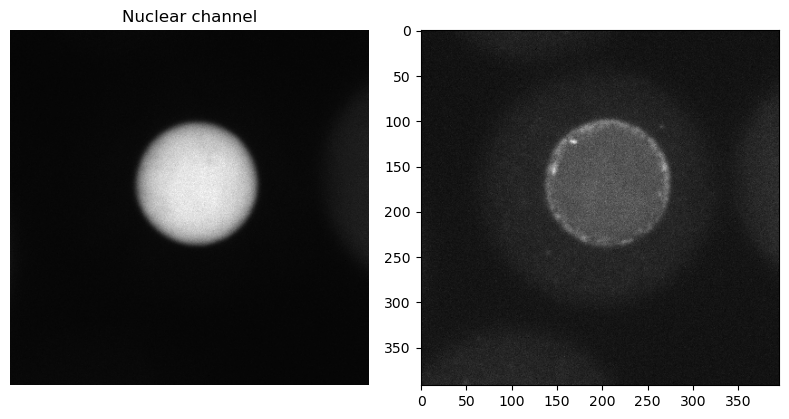

In [ ]:
#### Simple Viewer Function for Single Droplet Image#### 
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology

# choose a time and z to play with
t_idx = 9  # 0..9 set the time point that you wish to view. In python 0 is the first indexing number. So time 1 is actually t index 0. 
z_idx = 16  # 0..19 set the z slice that you wish to view. In python 0 is the first indexing number. So z slice 1 is actually z index 0.

NUC_CH = 1   # <-- Nuclus Channel When using a multi channel hyper stack you will define which of your channels contains which feature. 
MEM_CH = 2   # <-- membrane / NPC channel

nuc2d = img[t_idx, z_idx, :, :, NUC_CH] # Extract 2D slice for nuclear channel at specified time and z index
mem2d = img[t_idx, z_idx, :, :, MEM_CH] # Extract 2D slice for membrane/NPC channel at specified time and z index

print("nuc2d shape:", nuc2d.shape) #desctiptors of the extracted image
print("mem2d shape:", mem2d.shape) #descriptors of the extracted image

# Display the images 
fig, ax = plt.subplots(1, 2, figsize=(8, 4)) # plt.subplots comes from matplotlib and is used to create a figure and a set of subplots. Fig, defindes the entire figure. where has 1, 2 is the differnt channels which we define below. Think of this as setting up the container for the plot. 
ax[0].imshow(nuc2d, cmap="gray"); ax[0].set_title("Nuclear channel"); ax[0].axis("off") # have defined 0 to use nuc2d image with index from above and given it a title. 
ax[1].imshow(mem2d, cmap="gray"); ax[1].set_title("NPC channel"); ax[1].axis("off") # we have defined 1 to use mem2d image with index from above and given it a title.
plt.tight_layout(); plt.show() #this is the actual command that displays the plot. plt. is the function where as tight_layout() is the format. 


In the following section we will define our threasholding for the various parts of the image for generating training images. 
In this example we are identifying three objects for image segmentation. Droplets, background, and Nuclei

In [ ]:
#### Droplet Detection Based on Histogram Threasholding ####
import numpy as np
from skimage import filters, morphology, measure
# def is the syntax to define a function in python we then name the function and finish with the parameters we wish to pass to the function. 
def segment_droplet_from_npc(npc2d, #we defined this object above when we extracted the 2d image from the hyper stack. 
                             puncta_quantile=0.80, # quantile to define bright puncta which we will exclude for the use of finding droplet background
                             blur_sigma=4.0,#applies a gaussian blur to smooth the image.
                             min_size=800,#minimum size of objects to keep
                             hole_area=3000): #maximum size of holes to fill
    """
    npc2d: 2D NPC channel slice (uint16 or float)
    Returns: binary droplet mask (True = inside droplet)
    """
    # 1. normalize to [0,1] this helps us generate a more conistant masking by making a binary decision. 
    npc_f = npc2d.astype("float32") #defined a new object npc_f and converted the data type to float32
    npc_f = (npc_f - npc_f.min()) / (npc_f.max() - npc_f.min() + 1e-8) # used the newly defined object to normalize the image to a range of 0 to 1.

    # 2. find high-intensity cutoff from histogram (tail) we will use this to remove objects in the droplet that are not part of the droplet background.
    thr_puncta = np.quantile(npc_f, puncta_quantile)

    # 3. clip very bright puncta down to droplet-background level which allows us to focus on the droplet background signal for identifying droplet region.
    npc_clean = npc_f.copy()
    npc_clean[npc_clean > thr_puncta] = thr_puncta

    # 4. strong blur to keep only droplet-scale signal
    npc_blur = filters.gaussian(npc_clean, sigma=blur_sigma)

    # 5. Otsu threshold on blurred image -> droplet vs outside
    thr = filters.threshold_otsu(npc_blur) #filters is a function from skimage. We are using the otsu function within skimage. 
    droplet_mask = npc_blur > thr # create a binary mask where the blurred image is greater than the threshold determined by otsu method.

    # 6. clean up geometry
    droplet_mask = morphology.binary_closing(droplet_mask, morphology.disk(3)) #morphology is a function from skimage. We are using the binary_closing function within skimage to close small holes in the binary mask.
    droplet_mask = morphology.remove_small_objects(droplet_mask,
                                                   min_size=min_size) #remove_small_objects is a function from skimage. We are using it to remove small objects from the binary mask.
    droplet_mask = morphology.remove_small_holes(droplet_mask,
                                                 area_threshold=hole_area) #remove_small_holes is a function from skimage. We are using it to fill small holes in the binary mask.
    return droplet_mask


Segmentation of the nuclear signal. we use the same functions as above. See above section for detailed explainations of line functions. 

In [29]:
#### Nucleus Segmentation Based on Gaussian Blur and Otsu Thresholding ####
from skimage import filters, morphology
def segment_nucleus_from_import(nuc2d, sigma=1.0, min_size=50):
    nuc_f = nuc2d.astype("float32")
    nuc_f = (nuc_f - nuc_f.min()) / (nuc_f.max() - nuc_f.min() + 1e-8)

    blur = filters.gaussian(nuc_f, sigma=sigma)
    thr = filters.threshold_otsu(blur)
    nucleus_mask = blur > thr

    nucleus_mask = morphology.remove_small_objects(nucleus_mask,
                                                   min_size=min_size)
    nucleus_mask = morphology.remove_small_holes(nucleus_mask,
                                                 area_threshold=min_size)
    return nucleus_mask


Now we will use the masks we generated above to define our objects of interest for our training set. 

In [ ]:
#### Image Labeling to Select Droplet Nearest Nucleus for Machine Learning ####
from skimage.measure import label as cc_label, regionprops

def select_droplet_near_nucleus(droplet_mask, nucleus_mask): #droplet_mask and nucleus_mask were defined above when we created the binary masks for the droplet and nucleus.
    """
    droplet_mask: binary mask with possibly multiple droplets
    nucleus_mask: binary mask for nucleus
    Returns: binary mask of the single droplet associated with that nucleus
    """
    lab = cc_label(droplet_mask)  # using cc_label here we are defining lab as the connected components label of the droplet mask. This will label each connected component (droplet) with a unique integer.
    props = regionprops(lab) # regionprops is a function from skimage that calculates properties of labeled image regions.

    if not props:
        return np.zeros_like(droplet_mask, dtype=bool)

    # nucleus centroid
    ny, nx = np.argwhere(nucleus_mask).mean(axis=0) #np.argwhere is a numpy function that returns the indices of the elements that are non-zero (True) in the input array. Here we are using it to find the centroid of the nucleus.

    # find droplet whose centroid is closest to nucleus centroid
    best_label = None # None is a placeholder for the best label until the loop finds the closest droplet.
    best_dist = np.inf #np.inf represents infinity in numpy. It is used here to initialize the best distance variable to a very large value. Ensuring that the droplet is the best canidate. 
    for p in props: #this is how we intiate a loop in python. We are looping over each droplet region found in the droplet mask. p is being defined in the for loop we don't define. 
        cy, cx = p.centroid #returns row, column or y,x coordinates of the centroid of the droplet region p.
        dist = (cy - ny)**2 + (cx - nx)**2 #calculates the squared distance between the centroid of the droplet region and the centroid of the nucleus.
        if dist < best_dist: # if the calculated distance is less than the best distance found so far we update the best distance and best label.
            best_dist = dist 
            best_label = p.label

    return lab == best_label 



In [31]:
##### Create 3-Class Label Image With Droplets, BG, And Nuclei Classified ####
def make_3class_label(droplet_mask, nucleus_mask):
    nucleus_mask = nucleus_mask & droplet_mask  # enforce inside droplet
    label = np.zeros_like(droplet_mask, dtype=np.uint8)
    label[droplet_mask] = 1
    label[nucleus_mask] = 2
    return label


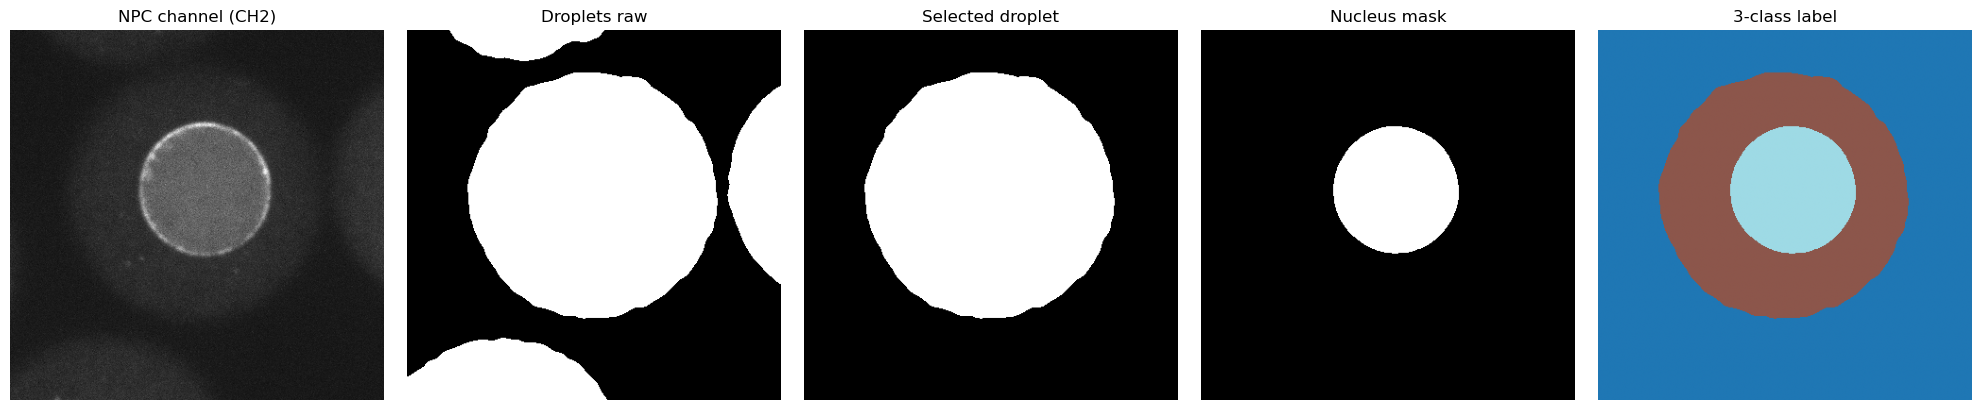

In [ ]:
#### Segmentation and Visualization Example for A Small FOV Image. Selctiing for a Single Timepoint and Z Slice ####
t, z = 9, 15
NPC_CH = 2
NUC_CH = 1

npc = img[t, z, :, :, NPC_CH] # :,: tells it to take all x and y pixel values in the designated slice. 
nuc = img[t, z, :, :, NUC_CH]

nucleus_mask_raw = segment_nucleus_from_import(nuc) #The function segment_nucleus_from_import is defined above where we have nuc = . We are passing the nuc object we just defined to that function to create a binary mask for the nucleus.
droplet_mask_raw = segment_droplet_from_npc(npc)

droplet_mask = select_droplet_near_nucleus(droplet_mask_raw, nucleus_mask_raw)
label        = make_3class_label(droplet_mask, nucleus_mask_raw)

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
ax[0].imshow(npc, cmap='gray');             ax[0].set_title("NPC channel (CH2)"); ax[0].axis('off')
ax[1].imshow(droplet_mask_raw, cmap='gray');ax[1].set_title("Droplets raw");      ax[1].axis('off')
ax[2].imshow(droplet_mask, cmap='gray');    ax[2].set_title("Selected droplet");  ax[2].axis('off')
ax[3].imshow(nucleus_mask_raw, cmap='gray');ax[3].set_title("Nucleus mask");      ax[3].axis('off')
ax[4].imshow(label, cmap='tab20');          ax[4].set_title("3-class label");     ax[4].axis('off')
plt.tight_layout(); plt.show()


Now we are applying what we tested using a single droplet above into a large FOV image. I have identified a fatal flaw that I must correct though. I have function defintions from the above section baked into this section. So if I don't run above this wont work. 


In [33]:
#### Large FOV Images For Actual Analiysis of Large Data Sets #### 
from pathlib import Path
from skimage import io

# Base directory (same as before)
DATA_ROOT = Path(r"C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama/Nuclear_Scaling/Data_Sets/Control")

# Point to your large field-of-view TIFF
# (Update this filename/path to match your actual FOV file)
FOV_PATH = DATA_ROOT / "Extract 3" / "Untitled.tif"

# Read in full-field image
img_fov = io.imread(FOV_PATH)

print("FOV Loaded:")
print("  Type:", type(img_fov))
print("  Shape:", img_fov.shape)
print("  Dtype:", img_fov.dtype)


FOV Loaded:
  Type: <class 'numpy.ndarray'>
  Shape: (10, 20, 3889, 5732, 3)
  Dtype: uint16


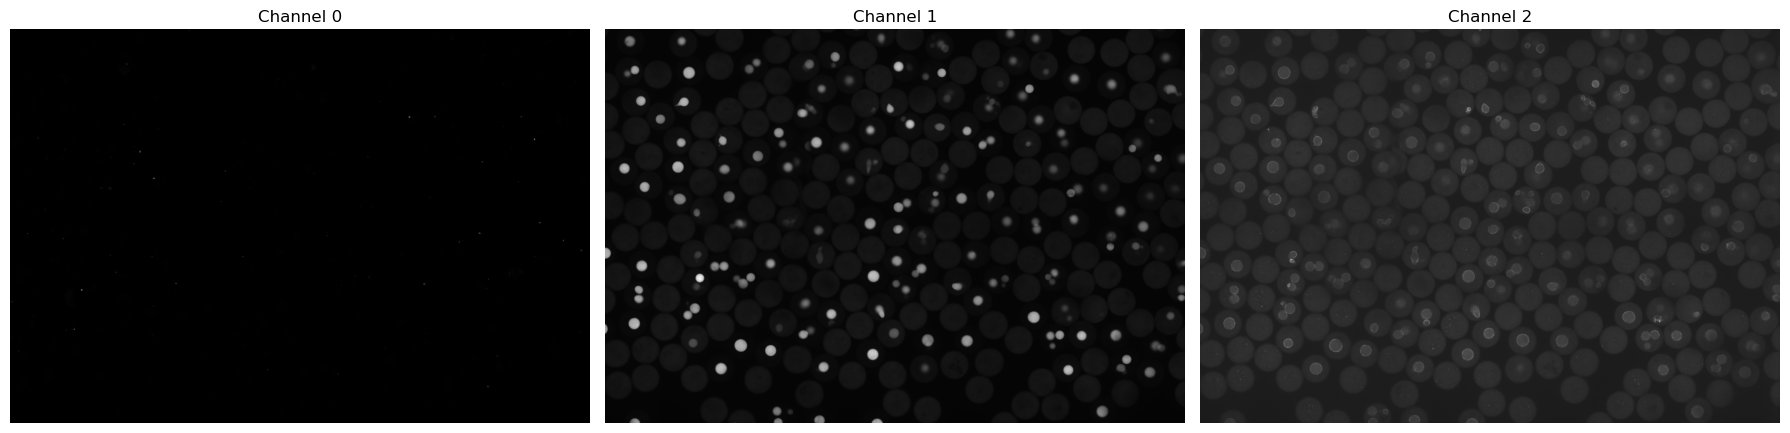

In [34]:
#### Visualization of Lage FOV Image Channels ####
#Currently clunky but works for now. I might add channel selection etc later
# Need to remember that it defines T1 as 0. So for a 10 timepoint image, T10 is index 9. 
import matplotlib.pyplot as plt

t = 9
z = 10

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for c in range(3):
    ax[c].imshow(img_fov[t, z, :, :, c], cmap='gray')
    ax[c].set_title(f"Channel {c}")
    ax[c].axis('off')

plt.tight_layout()
plt.show()


In [35]:
#### Threasholding Segment for Multi-Droplet Images #### 
import pandas as pd

def analyze_field(npc2d, nuc2d):
    # 1) segment
    droplet_mask = segment_droplet_from_npc(npc2d)
    nucleus_mask = segment_nucleus_from_import(nuc2d)

    # 2) label connected components
    droplet_labels = cc_label(droplet_mask)  # 0 = background, 1..Ndroplets
    nucleus_labels = cc_label(nucleus_mask)  # 0 = background, 1..Nnuclei

    # 3) measure droplets and nuclei
    droplet_props = regionprops_table(
        droplet_labels,
        properties=["label", "area", "centroid"]
    )
    nuc_props = regionprops_table(
        nucleus_labels,
        properties=["label", "area", "centroid"]
    )

    droplet_df = pd.DataFrame(droplet_props).rename(
        columns={"label": "droplet_label",
                 "centroid-0": "droplet_cy",
                 "centroid-1": "droplet_cx"}
    )
    nuc_df = pd.DataFrame(nuc_props).rename(
        columns={"label": "nucleus_label",
                 "centroid-0": "nuc_cy",
                 "centroid-1": "nuc_cx"}
    )

    # 4) for each nucleus, find which droplet it belongs to
    droplet_ids_for_nuclei = []
    for cy, cx in zip(nuc_df["nuc_cy"], nuc_df["nuc_cx"]):
        iy, ix = int(round(cy)), int(round(cx))
        droplet_id = droplet_labels[iy, ix]  # 0 if not in any droplet
        droplet_ids_for_nuclei.append(droplet_id)

    nuc_df["droplet_label"] = droplet_ids_for_nuclei

    # keep only nuclei that lie inside a droplet
    nuc_df = nuc_df[nuc_df["droplet_label"] > 0].reset_index(drop=True)

    # 5) optional: merge info (e.g., droplet size with its nuclei)
    merged = nuc_df.merge(droplet_df, on="droplet_label", how="left",
                          suffixes=("_nuc", "_drop"))

    return droplet_labels, nucleus_labels, droplet_df, nuc_df, merged


In [36]:
def make_3class_label_full(droplet_labels, nucleus_labels):
    label_3c = np.zeros_like(droplet_labels, dtype=np.uint8)
    label_3c[droplet_labels > 0] = 1
    label_3c[nucleus_labels > 0] = 2  # overwrite where nuclei are
    return label_3c


In [37]:
#### Just a sanity check to extract channels from large FOV image ####
t = 9
z = 15

# Extract the correct channels from your 5D hyperstack
npc2d = img_fov[t, z, :, :, NPC_CH]   # NPC channel (droplet channel)
nuc2d = img_fov[t, z, :, :, NUC_CH]   # nuclear-import channel (nucleus channel)

print("npc2d shape:", npc2d.shape)
print("nuc2d shape:", nuc2d.shape)


npc2d shape: (3889, 5732)
nuc2d shape: (3889, 5732)


In [38]:
from skimage.measure import label as cc_label, regionprops, regionprops_table

droplet_labels, nucleus_labels, droplet_df, nuc_df, merged = analyze_field(npc2d, nuc2d)
label_3c = make_3class_label_full(droplet_labels, nucleus_labels)


In [39]:
print("droplet_labels shape:", droplet_labels.shape)
print("nucleus_labels shape:", nucleus_labels.shape)
print("unique droplet labels:", np.unique(droplet_labels)[:10])
print("unique nucleus labels:", np.unique(nucleus_labels)[:10])


droplet_labels shape: (3889, 5732)
nucleus_labels shape: (3889, 5732)
unique droplet labels: [0 1 2 3 4 5 6 7 8 9]
unique nucleus labels: [0 1 2 3 4 5 6 7 8 9]


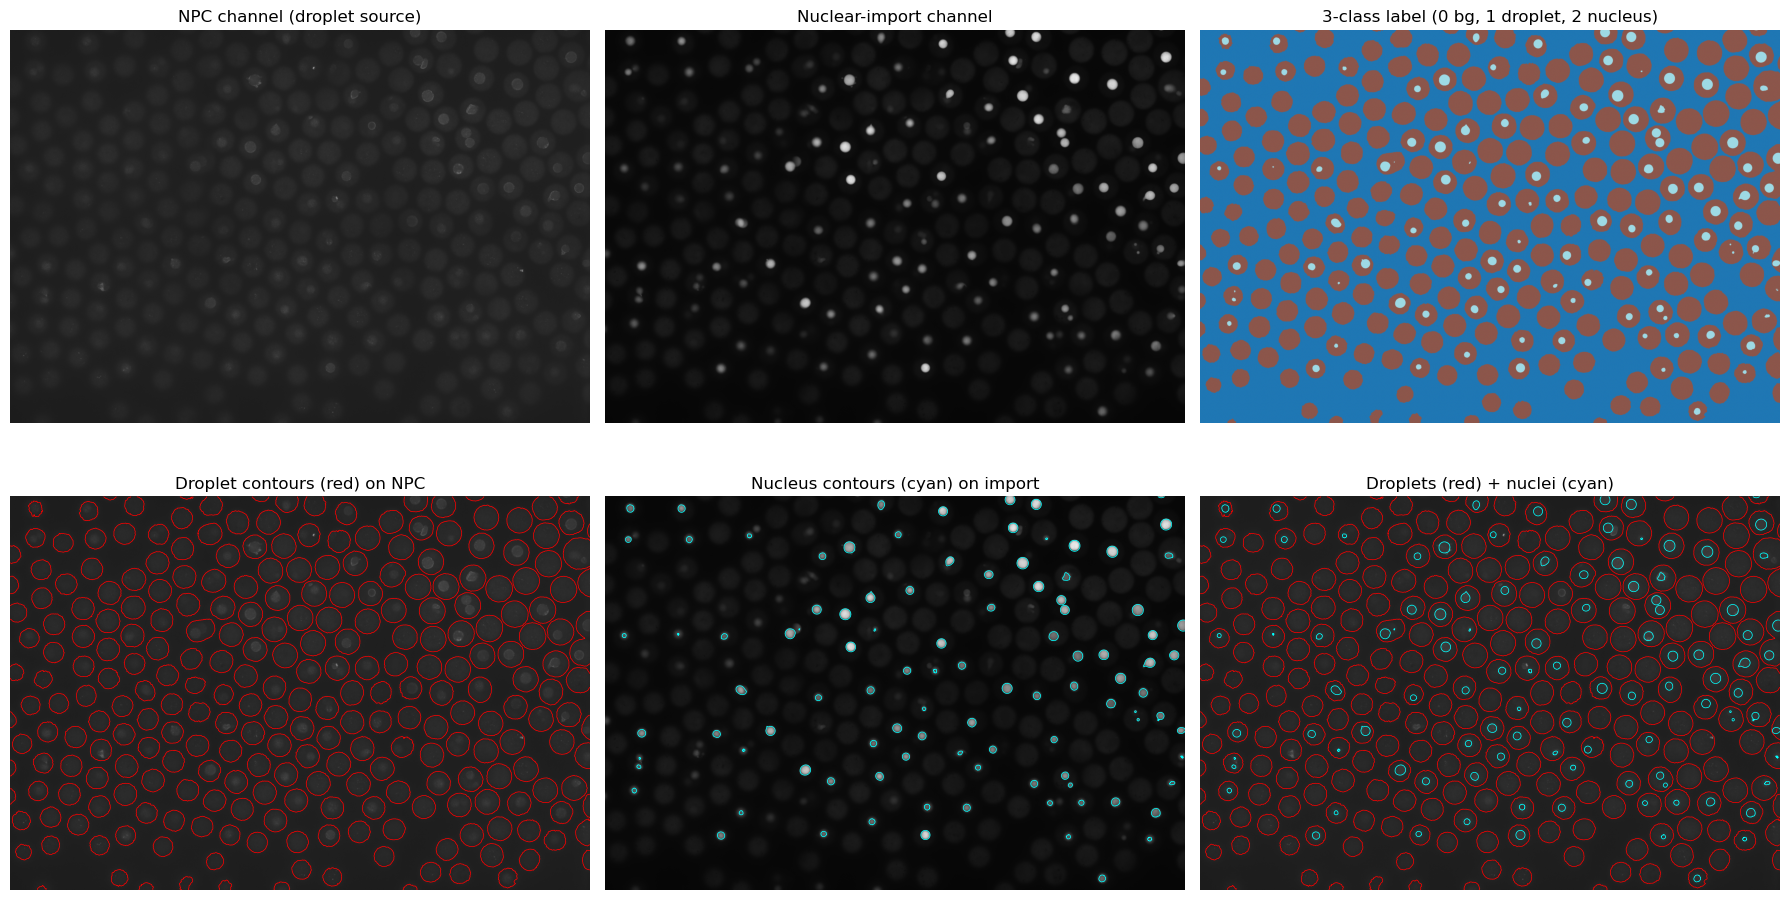

In [40]:
#### Visualization of Segmentation Results on Large FOV Image ####
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: raw intensity images
ax[0, 0].imshow(npc2d, cmap='gray')
ax[0, 0].set_title("NPC channel (droplet source)")
ax[0, 0].axis('off')

ax[0, 1].imshow(nuc2d, cmap='gray')
ax[0, 1].set_title("Nuclear-import channel")
ax[0, 1].axis('off')

ax[0, 2].imshow(label_3c, cmap='tab20')
ax[0, 2].set_title("3-class label (0 bg, 1 droplet, 2 nucleus)")
ax[0, 2].axis('off')

# Row 2: overlays
ax[1, 0].imshow(npc2d, cmap='gray')
ax[1, 0].contour(droplet_labels > 0, colors='red', linewidths=0.5)
ax[1, 0].set_title("Droplet contours (red) on NPC")
ax[1, 0].axis('off')

ax[1, 1].imshow(nuc2d, cmap='gray')
ax[1, 1].contour(nucleus_labels > 0, colors='cyan', linewidths=0.5)
ax[1, 1].set_title("Nucleus contours (cyan) on import")
ax[1, 1].axis('off')

ax[1, 2].imshow(npc2d, cmap='gray')
ax[1, 2].contour(droplet_labels > 0, colors='red', linewidths=0.5)
ax[1, 2].contour(nucleus_labels > 0, colors='cyan', linewidths=0.5)
ax[1, 2].set_title("Droplets (red) + nuclei (cyan)")
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()


This is where the start of Building our Training Data Set for machine learning Starts Currenrly has some dependancies upstream that will need to be fixed. 

In [41]:
from pathlib import Path
import os
import numpy as np

# Where the big hyperstack is (you already loaded it as img_fov)
# img_fov.shape == (T, Z, Y, X, C)
print("Hyperstack shape:", img_fov.shape)

# Channel indices (adjust if needed after you visualize)
MEM_CH = 0      # membrane channel (optional; nice contextual input)
NUC_CH = 1      # nuclear-import channel (nucleus interior)
NPC_CH = 2      # NPC channel (droplet source)

# Output root for training dataset
OUT_ROOT = Path(r"C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama/Nuclear_Scaling/ML_training")
IMG_OUT  = OUT_ROOT / "images"
LAB_OUT  = OUT_ROOT / "labels"

IMG_OUT.mkdir(parents=True, exist_ok=True)
LAB_OUT.mkdir(parents=True, exist_ok=True)

# Patch params
PATCH_SIZE = 256      # spatial size of patches (256 or 512 is common)
STRIDE     = 256      # step between patches (use < PATCH_SIZE for overlap)
MIN_FG_FRAC = 0.01    # minimum fraction of non-background pixels to keep a patch


Hyperstack shape: (10, 20, 3889, 5732, 3)


In [42]:
from skimage import filters, morphology
from skimage.measure import label as cc_label, regionprops_table

def segment_droplet_from_npc(npc2d,
                             puncta_quantile=0.80,
                             blur_sigma=4.0,
                             min_size=800,
                             hole_area=3000):
    """
    Droplet mask from NPC channel for a 2D slice.
    """
    npc_f = npc2d.astype("float32")
    npc_f = (npc_f - npc_f.min()) / (npc_f.max() - npc_f.min() + 1e-8)

    # clip bright NPC puncta
    thr = np.quantile(npc_f, puncta_quantile)
    npc_clean = np.clip(npc_f, 0, thr) / (thr + 1e-8)

    # smooth to keep large-scale droplet structure
    npc_blur = filters.gaussian(npc_clean, sigma=blur_sigma)

    # threshold for droplet vs background
    val = filters.threshold_otsu(npc_blur)
    droplet_mask = npc_blur > val

    # cleanup
    droplet_mask = morphology.binary_closing(droplet_mask, morphology.disk(3))
    droplet_mask = morphology.remove_small_objects(droplet_mask,
                                                   min_size=min_size)
    droplet_mask = morphology.remove_small_holes(droplet_mask,
                                                 area_threshold=hole_area)

    return droplet_mask

def segment_nucleus_from_import(nuc2d, sigma=1.0, min_size=50):
    """
    Nucleus mask from nuclear-import channel for a 2D slice.
    """
    nuc_f = nuc2d.astype("float32")
    nuc_f = (nuc_f - nuc_f.min()) / (nuc_f.max() - nuc_f.min() + 1e-8)

    blur = filters.gaussian(nuc_f, sigma=sigma)
    thr = filters.threshold_otsu(blur)
    nucleus_mask = blur > thr

    nucleus_mask = morphology.remove_small_objects(nucleus_mask,
                                                   min_size=min_size)
    nucleus_mask = morphology.remove_small_holes(nucleus_mask,
                                                 area_threshold=min_size)
    return nucleus_mask

#def make_3class_label_full(droplet_mask, nucleus_mask):
    """
    Build 3-class label image:
      0 = background
      1 = droplet
      2 = nucleus (inside droplet)
    """
    nucleus_mask = nucleus_mask & droplet_mask
    label_3c = np.zeros_like(droplet_mask, dtype=np.uint8)
    label_3c[droplet_mask] = 1
    label_3c[nucleus_mask] = 2
    return label_3c

def make_3class_label_full(droplet_mask, nucleus_mask, max_nucleus_frac=0.4):
    """
    Build 3-class label image:
      0 = background
      1 = droplet
      2 = nucleus (inside droplet, and not too big)

    If the 'nucleus' fills too much of the droplet (e.g. out-of-focus slice),
    we drop the nucleus label but KEEP the droplet label.
    """
    droplet_mask = droplet_mask.astype(bool)
    nucleus_mask = nucleus_mask.astype(bool) & droplet_mask  # enforce inside droplet

    droplet_area = np.sum(droplet_mask)
    nucleus_area = np.sum(nucleus_mask)

    frac = nucleus_area / droplet_area if droplet_area > 0 else 0.0

    # if nucleus fills too much of the droplet, treat as no nucleus
    if frac > max_nucleus_frac:
        nucleus_mask[:] = False

    label_3c = np.zeros_like(droplet_mask, dtype=np.uint8)
    label_3c[droplet_mask] = 1     # droplets always labeled as 1
    label_3c[nucleus_mask] = 2     # nuclei only if valid
    return label_3c

In [43]:
def normalize_channel(ch2d):
    ch = ch2d.astype("float32")
    ch = ch - ch.min()
    if ch.max() > 0:
        ch = ch / ch.max()
    return ch

def build_input_image(mem2d, nuc2d, npc2d):
    """
    Returns H×W×3 float32 in [0,1].
    Channel order: [nuclear-import, NPC, membrane]
    """
    nuc_norm = normalize_channel(nuc2d)
    npc_norm = normalize_channel(npc2d)
    mem_norm = normalize_channel(mem2d)

    x = np.stack([nuc_norm, npc_norm, mem_norm], axis=-1)
    return x.astype("float32")


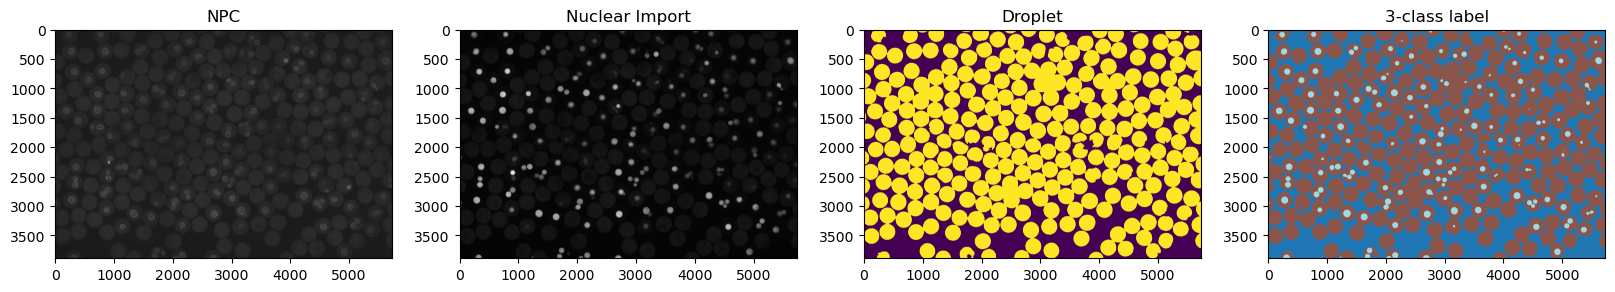

In [44]:
# Addding some checks for label crearting before running my big stuff 
# With Nuclei test
t = 0
z = 10   # pick a Z where nucleus is sharp

npc2d = img_fov[t, z, :, :, NPC_CH]
nuc2d = img_fov[t, z, :, :, NUC_CH]

droplet_mask = segment_droplet_from_npc(npc2d)
nucleus_mask = segment_nucleus_from_import(nuc2d)

label_test = make_3class_label_full(droplet_mask, nucleus_mask)

plt.figure(figsize=(20,4))
plt.subplot(1,4,1); plt.imshow(npc2d, cmap='gray'); plt.title("NPC")
plt.subplot(1,4,2); plt.imshow(nuc2d, cmap='gray'); plt.title("Nuclear Import")
plt.subplot(1,4,3); plt.imshow(droplet_mask); plt.title("Droplet")
plt.subplot(1,4,4); plt.imshow(label_test, cmap='tab20'); plt.title("3-class label")
plt.show()


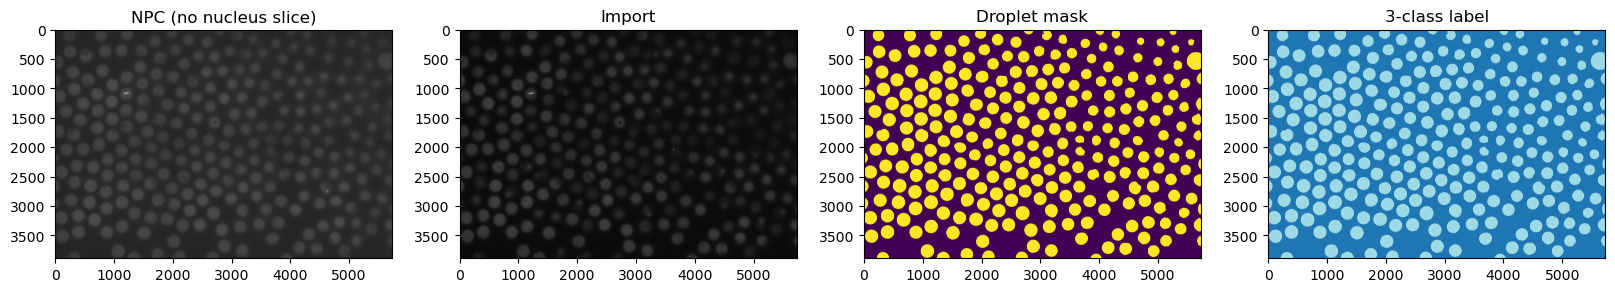

In [ ]:
#### No Nuclei test #### 
t = 0
z = 2   # or 0 or 18 or 19

npc2d = img_fov[t, z, :, :, NPC_CH]
nuc2d = img_fov[t, z, :, :, NUC_CH]

droplet_mask = segment_droplet_from_npc(npc2d)
nucleus_mask = segment_nucleus_from_import(nuc2d)

label_test = make_3class_label_full(droplet_mask, nucleus_mask)

plt.figure(figsize=(20,4))
plt.subplot(1,4,1); plt.imshow(npc2d, cmap='gray'); plt.title("NPC (no nucleus slice)")
plt.subplot(1,4,2); plt.imshow(nuc2d, cmap='gray'); plt.title("Import")
plt.subplot(1,4,3); plt.imshow(droplet_mask); plt.title("Droplet mask")
plt.subplot(1,4,4); plt.imshow(label_test, cmap='tab20'); plt.title("3-class label")
plt.show()


In [45]:
from tqdm import tqdm  # if you don't have it: pip install tqdm

def build_unet_dataset_from_hyperstack(img_fov,
                                       out_images=IMG_OUT,
                                       out_labels=LAB_OUT,
                                       patch_size=PATCH_SIZE,
                                       stride=STRIDE,
                                       min_fg_frac=MIN_FG_FRAC):
    T, Z, H, W, C = img_fov.shape
    patch_id = 0

    for t in range(T):
        for z in range(Z):
            # extract channels for this slice
            mem2d = img_fov[t, z, :, :, MEM_CH]
            nuc2d = img_fov[t, z, :, :, NUC_CH]
            npc2d = img_fov[t, z, :, :, NPC_CH]

            # segment droplets & nuclei
            droplet_mask = segment_droplet_from_npc(npc2d)
            nucleus_mask = segment_nucleus_from_import(nuc2d)
            label_3c = make_3class_label_full(droplet_mask, nucleus_mask)

            # build input image (H×W×3)
            x = build_input_image(mem2d, nuc2d, npc2d)

            # slide window over FOV
            for y in range(0, H - patch_size + 1, stride):
                for x0 in range(0, W - patch_size + 1, stride):
                    x_patch = x[y:y+patch_size, x0:x0+patch_size, :]
                    y_patch = label_3c[y:y+patch_size, x0:x0+patch_size]

                    # skip mostly empty patches
                    fg_frac = np.mean(y_patch > 0)
                    if fg_frac < min_fg_frac:
                        continue

                    img_fname = out_images / f"img_t{t:02d}_z{z:02d}_y{y:04d}_x{x0:04d}_p{patch_id:05d}.npy"
                    lab_fname = out_labels / f"lab_t{t:02d}_z{z:02d}_y{y:04d}_x{x0:04d}_p{patch_id:05d}.npy"

                    np.save(img_fname, x_patch)
                    np.save(lab_fname, y_patch.astype("uint8"))

                    patch_id += 1

    print(f"Finished. Saved {patch_id} patches.")


In [57]:
#### Use Command for building the Patches as defined above ####
build_unet_dataset_from_hyperstack(img_fov)


Finished. Saved 64972 patches.


In [ ]:
#### DANGER!!!!!! CLEARS PREVIOUS PATCHES DON'T JUST PRESS THE BUTTON YOU MONKEY!#### 
#import shutil
#shutil.rmtree(IMG_OUT)
#shutil.rmtree(LAB_OUT)
#IMG_OUT.mkdir(parents=True, exist_ok=True)
#LAB_OUT.mkdir(parents=True, exist_ok=True)


In [ ]:
#### Sanity Check to List Saved Image and Label Patches ####
list(IMG_OUT.iterdir()), list(LAB_OUT.iterdir())


In [1]:
#### Currenltly Redundant as I am defining in next function But I might like this better#### 
from pathlib import Path

OUT_ROOT = Path(r"C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama/Nuclear_Scaling/ML_training")
IMG_OUT  = OUT_ROOT / "images"
LAB_OUT  = OUT_ROOT / "labels"

print("Images directory:", IMG_OUT)
print("Labels directory:", LAB_OUT)

print("Number of images:", len(list(IMG_OUT.glob("*.npy"))))
print("Number of labels:", len(list(LAB_OUT.glob("*.npy"))))



Images directory: C:\Users\cowboy\OneDrive\Documents\Unviversity of Alabama\Nuclear_Scaling\ML_training\images
Labels directory: C:\Users\cowboy\OneDrive\Documents\Unviversity of Alabama\Nuclear_Scaling\ML_training\labels
Number of images: 54216
Number of labels: 64972


Patch image shape: (256, 256, 3)
Patch label shape: (256, 256)


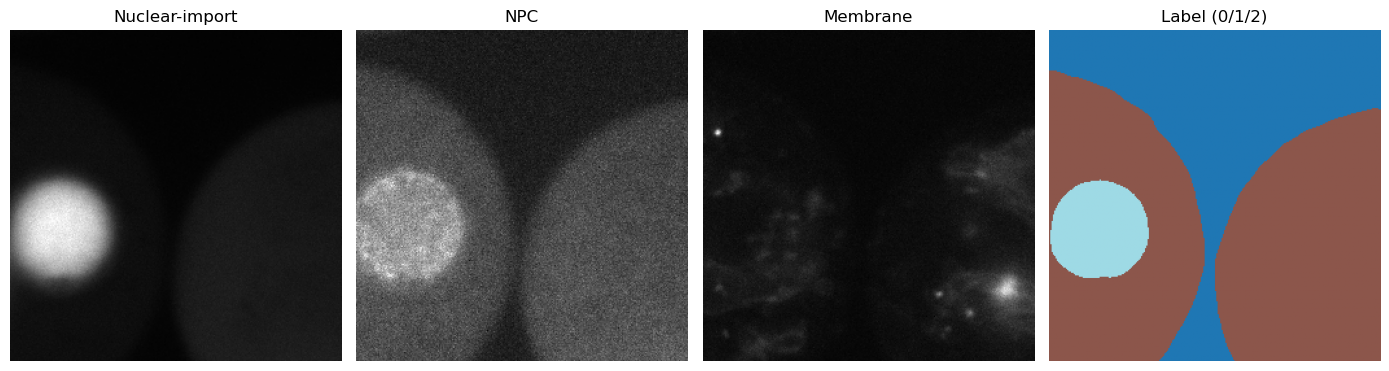

In [108]:
import numpy as np
import random
import matplotlib.pyplot as plt

# pick a random image patch
example_img = random.choice(list(IMG_OUT.glob("*.npy")))

# convert its filename to the matching label filename
example_lab = LAB_OUT / example_img.name.replace("img_", "lab_")

# load
x = np.load(example_img)
y = np.load(example_lab)

print("Patch image shape:", x.shape)
print("Patch label shape:", y.shape)

# visualize
fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(x[..., 0], cmap='gray'); ax[0].set_title("Nuclear-import"); ax[0].axis("off")
ax[1].imshow(x[..., 1], cmap='gray'); ax[1].set_title("NPC");            ax[1].axis("off")
ax[2].imshow(x[..., 2], cmap='gray'); ax[2].set_title("Membrane");       ax[2].axis("off")
ax[3].imshow(y, cmap='tab20');         ax[3].set_title("Label (0/1/2)"); ax[3].axis("off")
plt.tight_layout(); plt.show()



U-Net Machine Learning Approach

In [6]:
import tensorflow as tf
print("TF version:", tf.__version__)


TF version: 2.20.0


In [7]:
from pathlib import Path
import numpy as np

# Root where your patches live (adjust if needed)
OUT_ROOT = Path(r"C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama/Nuclear_Scaling/ML_training")
IMG_OUT  = OUT_ROOT / "images"
LAB_OUT  = OUT_ROOT / "labels"

# Basic settings
PATCH_SIZE   = 256          # must match your patch builder
NUM_CHANNELS = 3            # [nuc import, NPC, membrane]
NUM_CLASSES  = 3            # background, droplet, nucleus
BATCH_SIZE   = 8            # tune based on GPU memory
VAL_FRAC     = 0.1          # fraction of patches for validation

# List patch files (will be reused after you rebuild)
img_paths = sorted(IMG_OUT.glob("*.npy"))
lab_paths = sorted(LAB_OUT.glob("*.npy"))

print(f"Found {len(img_paths)} image patches, {len(lab_paths)} label patches.")


Found 54216 image patches, 64972 label patches.


In [9]:
# Build dictionaries keyed by the shared ID part of the filename
img_by_id = {}
for p in img_paths:
    patch_id = p.name.replace("img_", "")  # everything after 'img_'
    img_by_id[patch_id] = p

lab_by_id = {}
for p in lab_paths:
    patch_id = p.name.replace("lab_", "")  # everything after 'lab_'
    lab_by_id[patch_id] = p

# Intersection of IDs that have BOTH image and label
common_ids = sorted(set(img_by_id.keys()) & set(lab_by_id.keys()))
print("Common patches:", len(common_ids))

# Now build *paired* lists
paired_img_paths = [img_by_id[i] for i in common_ids]
paired_lab_paths = [lab_by_id[i] for i in common_ids]

print("Paired images:", len(paired_img_paths))
print("Paired labels:", len(paired_lab_paths))


Common patches: 54216
Paired images: 54216
Paired labels: 54216


In [15]:
import numpy as np

VAL_FRAC = 0.1  # or whatever you like

n = len(paired_img_paths)
indices = np.arange(n)
np.random.shuffle(indices)

n_val = int(n * VAL_FRAC)
val_idx   = indices[:n_val]
train_idx = indices[n_val:]

train_img_paths = [paired_img_paths[i] for i in train_idx]
train_lab_paths = [paired_lab_paths[i] for i in train_idx]
val_img_paths   = [paired_img_paths[i] for i in val_idx]
val_lab_paths   = [paired_lab_paths[i] for i in val_idx]

print(f"Train patches: {len(train_img_paths)} | Val patches: {len(val_img_paths)}")


Train patches: 48795 | Val patches: 5421


In [18]:
import numpy as np
import tensorflow as tf

def load_npy_pair(img_path, lab_path):
    """
    Python function used by tf.numpy_function.

    img_path, lab_path come in as 0-d numpy arrays of dtype=bytes,
    or sometimes as np.bytes_. We convert them to normal Python strings,
    then load with np.load.
    """
    # Handle 0-d numpy arrays
    if isinstance(img_path, np.ndarray):
        img_path = img_path.item()
    if isinstance(lab_path, np.ndarray):
        lab_path = lab_path.item()

    # Now img_path / lab_path should be bytes; decode to str
    if isinstance(img_path, bytes):
        img_path = img_path.decode("utf-8")
    if isinstance(lab_path, bytes):
        lab_path = lab_path.decode("utf-8")

    img = np.load(img_path)   # (H,W,3)
    lab = np.load(lab_path)   # (H,W)

    return img.astype("float32"), lab.astype("int32")


def tf_load_npy_pair(img_path, lab_path):
    img, lab = tf.numpy_function(
        load_npy_pair,
        [img_path, lab_path],
        [tf.float32, tf.int32]
    )

    # Set static shapes so TF knows dimensions
    img.set_shape((PATCH_SIZE, PATCH_SIZE, NUM_CHANNELS))
    lab.set_shape((PATCH_SIZE, PATCH_SIZE))

    # One-hot encode labels to (H, W, NUM_CLASSES)
    lab_oh = tf.one_hot(lab, depth=NUM_CLASSES, dtype=tf.float32)
    return img, lab_oh


In [19]:
train_ds = make_dataset(train_img_paths, train_lab_paths, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_img_paths,   val_lab_paths,   BATCH_SIZE, shuffle=False)


In [20]:
for x_batch, y_batch in train_ds.take(1):
    print("x_batch:", x_batch.shape, x_batch.dtype)
    print("y_batch:", y_batch.shape, y_batch.dtype)


x_batch: (8, 256, 256, 3) <dtype: 'float32'>
y_batch: (8, 256, 256, 3) <dtype: 'float32'>


In [21]:
#### Build U-Net Model for 3-Class Segmentation ####
from tensorflow.keras import layers, models

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(PATCH_SIZE, PATCH_SIZE, NUM_CHANNELS),
               num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)

    # Bottleneck
    bn = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(bn, c4, 512)
    d2 = decoder_block(d1, c3, 256)
    d3 = decoder_block(d2, c2, 128)
    d4 = decoder_block(d3, c1, 64)

    # Output: per-pixel softmax over 3 classes
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(d4)

    model = models.Model(inputs, outputs, name="UNet_droplet_nucleus")
    return model

model = build_unet()
model.summary()


Model: "UNet_droplet_nucleus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,427 (118.47 MB)

 Trainable params: 31,043,651 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

Compile and Train U-Net Model 


In [22]:
#### Compile Model with Custom IoU Metric ####
loss = tf.keras.losses.CategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

def iou_metric(y_true, y_pred, eps=1e-6):
    # y_true, y_pred: (B,H,W,C) one-hot
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # predicted class via argmax
    y_pred_cls = tf.argmax(y_pred, axis=-1)
    y_true_cls = tf.argmax(y_true, axis=-1)

    # ignore background (class 0) if you want; here we compute macro IoU
    ious = []
    for c in range(1, NUM_CLASSES):  # skip 0 if you like
        y_true_c = tf.cast(tf.equal(y_true_cls, c), tf.float32)
        y_pred_c = tf.cast(tf.equal(y_pred_cls, c), tf.float32)
        inter = tf.reduce_sum(y_true_c * y_pred_c)
        union = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c) - inter + eps
        ious.append((inter + eps) / union)
    return tf.reduce_mean(ious)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy", iou_metric]
)


In [23]:
#### Train Model with Callbacks ####
EPOCHS = 5  # adjust later

checkpoint_dir = OUT_ROOT / "models"
checkpoint_dir.mkdir(exist_ok=True)
checkpoint_path = checkpoint_dir / "unet_droplet_nucleus_best.h5"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/5
 296/6100 ━━━━━━━━━━━━━━━━━━━━ 13:04:16 8s/step - accuracy: 0.6756 - iou_metric: 0.3827 - loss: 0.7836

KeyboardInterrupt: 

In [ ]:
#### Visualize Example Predictions on Validation Set ####
import matplotlib.pyplot as plt

# take one batch from val set
for x_batch, y_batch in val_ds.take(1):
    break

y_pred = model.predict(x_batch)

x0 = x_batch[0]
y0_true = y_batch[0]
y0_pred = y_pred[0]

y0_true_cls = tf.argmax(y0_true, axis=-1).numpy()
y0_pred_cls = tf.argmax(y0_pred, axis=-1).numpy()

fig, ax = plt.subplots(1, 5, figsize=(16, 4))
ax[0].imshow(x0[..., 0], cmap="gray"); ax[0].set_title("Nuclear-import"); ax[0].axis("off")
ax[1].imshow(x0[..., 1], cmap="gray"); ax[1].set_title("NPC");            ax[1].axis("off")
ax[2].imshow(x0[..., 2], cmap="gray"); ax[2].set_title("Membrane");       ax[2].axis("off")
ax[3].imshow(y0_true_cls, cmap="tab20"); ax[3].set_title("GT label");     ax[3].axis("off")
ax[4].imshow(y0_pred_cls, cmap="tab20"); ax[4].set_title("Pred label");   ax[4].axis("off")
plt.tight_layout(); plt.show()


# Improved U-Net Training Label Pipeline v2

This section is designed to replace the older thresholding/training-label workflow. The goal is to improve the training masks before retraining the U-Net.

Main changes:

1. **Nuclei are converted into filled solid objects** using closing, hole filling, convex hull cleanup, and minimum area filtering.
2. **NPC puncta are suppressed before droplet segmentation** using percentile clipping plus strong Gaussian low-pass filtering.
3. **Out-of-focus Z planes can be skipped** using both a manual top/bottom Z margin and an optional focus-score filter.
4. **Area cutoffs are specified in µm²** and converted internally to pixels.
5. **Training uses a weighted Dice + cross entropy loss** so small nuclear objects are not overwhelmed by background/droplet pixels.


In [ ]:
#### Improved Configuration ####
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import filters, morphology, measure, segmentation
from skimage.measure import label as cc_label, regionprops, regionprops_table
from scipy import ndimage as ndi

# -------------------------------------------------------------------------
# IMPORTANT: verify this value for your microscope/camera/objective settings.
# If your true scale is 0.612 µm/px, then 50 µm² ≈ 134 px.
# If your true scale is 6.12 µm/px, then 50 µm² ≈ 2 px, which is not useful.
# -------------------------------------------------------------------------
PIXEL_SIZE_UM = 0.612

# Channel indices for img_fov shaped as (T, Z, Y, X, C)
MEM_CH = 0
NUC_CH = 1
NPC_CH = 2

# Label classes
BG_CLASS = 0
DROPLET_CLASS = 1
NUCLEUS_CLASS = 2
NUM_CLASSES = 3

# Area thresholds in physical units
MIN_NUCLEUS_AREA_UM2 = 50
MIN_DROPLET_AREA_UM2 = 500        # adjust upward if small off-target droplets persist
HOLE_AREA_UM2 = 3000

# Z filtering: avoid training on top/bottom planes where artifacts dominate
Z_MARGIN = 2                      # skip z=0,1 and final 2 planes
USE_FOCUS_FILTER = True
FOCUS_QUANTILE_WITHIN_TIME = 0.25 # keep planes above this focus score within each time point

# Patch output directory
OUT_ROOT = Path(r"C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama/Nuclear_Scaling/ML_training_v2")
IMG_OUT  = OUT_ROOT / "images"
LAB_OUT  = OUT_ROOT / "labels"
QC_OUT   = OUT_ROOT / "qc"

for p in [IMG_OUT, LAB_OUT, QC_OUT]:
    p.mkdir(parents=True, exist_ok=True)

PATCH_SIZE = 256
STRIDE = 256
MIN_FG_FRAC = 0.01

print("Minimum nucleus area in pixels:", int(np.ceil(MIN_NUCLEUS_AREA_UM2 / PIXEL_SIZE_UM**2)))
print("Minimum droplet area in pixels:", int(np.ceil(MIN_DROPLET_AREA_UM2 / PIXEL_SIZE_UM**2)))


In [ ]:
#### Unit Conversion Helpers ####
def area_um2_to_px(area_um2, pixel_size_um=PIXEL_SIZE_UM):
    """Convert area in square microns to area in pixels."""
    return int(np.ceil(area_um2 / (pixel_size_um ** 2)))


def normalize01(img2d, lower_percentile=1, upper_percentile=99.8):
    """
    Robustly normalize a 2D image to [0, 1] using percentile clipping.
    This avoids one extremely bright punctum setting the entire intensity scale.
    """
    x = img2d.astype("float32")
    lo, hi = np.percentile(x, [lower_percentile, upper_percentile])
    x = np.clip(x, lo, hi)
    return (x - lo) / (hi - lo + 1e-8)


In [ ]:
#### Improved Droplet Segmentation from NPC Channel ####
def segment_droplet_from_npc_v2(
    npc2d,
    pixel_size_um=PIXEL_SIZE_UM,
    puncta_clip_quantile=0.98,
    blur_sigma=8.0,
    min_area_um2=MIN_DROPLET_AREA_UM2,
    hole_area_um2=HOLE_AREA_UM2,
    closing_radius_um=2.0,
):
    """
    Segment droplet-scale signal from the NPC channel.

    Why this differs from the original:
    - The previous puncta_quantile=0.80 clipped the brightest 20% of all pixels.
      That is a percentile operation, not an intensity cutoff of 0.8.
    - Here, we robustly normalize, clip only the brightest puncta tail, then use
      a much stronger Gaussian blur so small nuclear pore puncta collapse into
      low-frequency droplet-scale signal.
    """
    min_size_px = area_um2_to_px(min_area_um2, pixel_size_um)
    hole_area_px = area_um2_to_px(hole_area_um2, pixel_size_um)
    closing_radius_px = max(1, int(round(closing_radius_um / pixel_size_um)))

    npc_f = normalize01(npc2d)

    # Suppress bright puncta. Quantile 0.98 means clip only the brightest 2%.
    clip_val = np.quantile(npc_f, puncta_clip_quantile)
    npc_clean = np.minimum(npc_f, clip_val)
    npc_clean = npc_clean / (npc_clean.max() + 1e-8)

    # Strong low-pass filter; this is the key step for ignoring puncta texture.
    npc_lowpass = filters.gaussian(npc_clean, sigma=blur_sigma, preserve_range=True)

    # Otsu on the low-pass image.
    try:
        thr = filters.threshold_otsu(npc_lowpass)
    except ValueError:
        return np.zeros_like(npc2d, dtype=bool)

    droplet_mask = npc_lowpass > thr

    # Geometry cleanup.
    droplet_mask = morphology.binary_closing(droplet_mask, morphology.disk(closing_radius_px))
    droplet_mask = morphology.remove_small_objects(droplet_mask, min_size=min_size_px)
    droplet_mask = morphology.remove_small_holes(droplet_mask, area_threshold=hole_area_px)

    # Optional: if droplets are expected to be round-ish, lightly smooth the boundary.
    droplet_mask = morphology.binary_opening(droplet_mask, morphology.disk(1))
    droplet_mask = morphology.binary_closing(droplet_mask, morphology.disk(2))

    return droplet_mask.astype(bool)


In [ ]:
#### Improved Solid Nucleus Label Generation ####
def fill_each_object_with_convex_hull(mask, min_area_px):
    """
    Fill fragmented/rim-like nucleus labels into solid objects one object at a time.
    This prevents the U-Net from learning that a nucleus should be only a rim.
    """
    lab = cc_label(mask)
    out = np.zeros_like(mask, dtype=bool)

    for region in regionprops(lab):
        if region.area < min_area_px:
            continue

        obj = lab == region.label
        obj = ndi.binary_fill_holes(obj)
        obj = morphology.binary_closing(obj, morphology.disk(3))

        # Convex hull fills ring/fragment gaps and encourages solid nuclear labels.
        # If this overfills irregular objects, switch to ndi.binary_fill_holes only.
        obj = morphology.convex_hull_image(obj)

        if obj.sum() >= min_area_px:
            out |= obj

    return out


def segment_nucleus_from_import_v2(
    nuc2d,
    pixel_size_um=PIXEL_SIZE_UM,
    sigma=1.5,
    min_area_um2=MIN_NUCLEUS_AREA_UM2,
    closing_radius_um=1.5,
    use_convex_hull=True,
):
    """
    Generate filled nucleus training labels from the nuclear-import channel.

    This is intentionally more aggressive than the original thresholding because
    the training label needs to teach the model that the nucleus class is solid,
    not a rim, crescent, or set of fragments.
    """
    min_area_px = area_um2_to_px(min_area_um2, pixel_size_um)
    closing_radius_px = max(1, int(round(closing_radius_um / pixel_size_um)))

    nuc_f = normalize01(nuc2d)
    blur = filters.gaussian(nuc_f, sigma=sigma, preserve_range=True)

    try:
        thr = filters.threshold_otsu(blur)
    except ValueError:
        return np.zeros_like(nuc2d, dtype=bool)

    nucleus_mask = blur > thr

    nucleus_mask = morphology.binary_closing(nucleus_mask, morphology.disk(closing_radius_px))
    nucleus_mask = ndi.binary_fill_holes(nucleus_mask)
    nucleus_mask = morphology.remove_small_objects(nucleus_mask, min_size=min_area_px)
    nucleus_mask = morphology.remove_small_holes(nucleus_mask, area_threshold=min_area_px)

    if use_convex_hull:
        nucleus_mask = fill_each_object_with_convex_hull(nucleus_mask, min_area_px=min_area_px)

    nucleus_mask = morphology.remove_small_objects(nucleus_mask, min_size=min_area_px)

    return nucleus_mask.astype(bool)


In [ ]:
#### Z-Plane Focus Filtering ####
def focus_score_laplacian(img2d):
    """
    Simple focus score: variance of a Laplacian-filtered image.
    Higher values usually mean sharper in-focus structure.
    """
    x = normalize01(img2d)
    lap = ndi.laplace(x)
    return float(np.var(lap))


def make_z_keep_table(img_fov, nuc_ch=NUC_CH, z_margin=Z_MARGIN,
                      use_focus_filter=USE_FOCUS_FILTER,
                      focus_quantile=FOCUS_QUANTILE_WITHIN_TIME):
    """
    Build a table indicating which T/Z planes should be used for training.
    This protects the model from learning high/low-Z artifact planes as real nuclei.
    """
    T, Z, H, W, C = img_fov.shape
    rows = []

    for t in range(T):
        scores = []
        for z in range(Z):
            score = focus_score_laplacian(img_fov[t, z, :, :, nuc_ch])
            scores.append(score)

        scores = np.array(scores)
        focus_cutoff = np.quantile(scores, focus_quantile) if use_focus_filter else -np.inf

        for z, score in enumerate(scores):
            keep_by_margin = (z >= z_margin) and (z < Z - z_margin)
            keep_by_focus = score >= focus_cutoff
            keep = keep_by_margin and keep_by_focus
            rows.append({
                "t": t,
                "z": z,
                "focus_score": score,
                "focus_cutoff_for_t": focus_cutoff,
                "keep_by_margin": keep_by_margin,
                "keep_by_focus": keep_by_focus,
                "keep_for_training": keep,
            })

    return pd.DataFrame(rows)


def plot_focus_table(z_keep_df):
    plt.figure(figsize=(8, 4))
    for t, df_t in z_keep_df.groupby("t"):
        plt.plot(df_t["z"], df_t["focus_score"], marker="o", label=f"t={t}")
    plt.xlabel("Z index")
    plt.ylabel("Focus score")
    plt.title("Focus score by Z plane")
    plt.tight_layout()
    plt.show()


In [ ]:
#### Build 3-Class Labels with Solid Nuclei and Droplet Boundary ####
def make_3class_label_v2(droplet_mask, nucleus_mask):
    """
    0 = background
    1 = droplet
    2 = nucleus

    Nucleus overwrites droplet where they overlap. Nucleus is constrained inside
    droplet only when a droplet mask exists at that location.
    """
    label = np.zeros_like(droplet_mask, dtype=np.uint8)
    label[droplet_mask] = DROPLET_CLASS

    # If droplet mask is imperfect, this line may remove valid nuclei.
    # Keep it on for cleaner training labels; turn off only during debugging.
    nucleus_inside = nucleus_mask & droplet_mask
    label[nucleus_inside] = NUCLEUS_CLASS

    return label


def build_input_image_v2(mem2d, nuc2d, npc2d):
    """
    H x W x 3 float32 input image.
    Channel order: nuclear import, NPC, membrane.
    """
    return np.stack([
        normalize01(nuc2d),
        normalize01(npc2d),
        normalize01(mem2d),
    ], axis=-1).astype("float32")


In [ ]:
#### QC: Test One Plane Before Rebuilding Dataset ####
# Pick a plane that should contain a real nucleus.
t = 9
z = 15

mem2d = img_fov[t, z, :, :, MEM_CH]
nuc2d = img_fov[t, z, :, :, NUC_CH]
npc2d = img_fov[t, z, :, :, NPC_CH]

droplet_mask_v2 = segment_droplet_from_npc_v2(npc2d)
nucleus_mask_v2 = segment_nucleus_from_import_v2(nuc2d)
label_v2 = make_3class_label_v2(droplet_mask_v2, nucleus_mask_v2)

fig, ax = plt.subplots(1, 5, figsize=(22, 4))
ax[0].imshow(npc2d, cmap="gray"); ax[0].set_title("NPC raw")
ax[1].imshow(nuc2d, cmap="gray"); ax[1].set_title("Nuclear raw")
ax[2].imshow(droplet_mask_v2, cmap="gray"); ax[2].set_title("Droplet mask v2")
ax[3].imshow(nucleus_mask_v2, cmap="gray"); ax[3].set_title("Solid nucleus mask v2")
ax[4].imshow(label_v2, cmap="tab20", vmin=0, vmax=2); ax[4].set_title("3-class label v2")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

print("Nucleus mask pixels:", int(nucleus_mask_v2.sum()))
print("Droplet mask pixels:", int(droplet_mask_v2.sum()))


In [ ]:
#### Dataset Builder v2 ####
from tqdm import tqdm

def build_unet_dataset_from_hyperstack_v2(
    img_fov,
    out_images=IMG_OUT,
    out_labels=LAB_OUT,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_fg_frac=MIN_FG_FRAC,
    clear_existing=False,
):
    """
    Build U-Net training patches using improved v2 masks.

    clear_existing=True will delete old .npy patches in the v2 output folders.
    """
    if clear_existing:
        for folder in [out_images, out_labels]:
            for p in folder.glob("*.npy"):
                p.unlink()

    z_keep_df = make_z_keep_table(img_fov)
    z_keep_df.to_csv(QC_OUT / "z_focus_keep_table.csv", index=False)

    T, Z, H, W, C = img_fov.shape
    patch_id = 0
    qc_rows = []

    for _, row in tqdm(z_keep_df.iterrows(), total=len(z_keep_df)):
        t = int(row["t"])
        z = int(row["z"])

        if not bool(row["keep_for_training"]):
            continue

        mem2d = img_fov[t, z, :, :, MEM_CH]
        nuc2d = img_fov[t, z, :, :, NUC_CH]
        npc2d = img_fov[t, z, :, :, NPC_CH]

        droplet_mask = segment_droplet_from_npc_v2(npc2d)
        nucleus_mask = segment_nucleus_from_import_v2(nuc2d)
        label_3c = make_3class_label_v2(droplet_mask, nucleus_mask)
        img_3c = build_input_image_v2(mem2d, nuc2d, npc2d)

        for y in range(0, H - patch_size + 1, stride):
            for x0 in range(0, W - patch_size + 1, stride):
                img_patch = img_3c[y:y+patch_size, x0:x0+patch_size, :]
                lab_patch = label_3c[y:y+patch_size, x0:x0+patch_size]

                fg_frac = np.mean(lab_patch > 0)
                nuc_frac = np.mean(lab_patch == NUCLEUS_CLASS)

                # Keep patches with enough foreground OR any meaningful nucleus content.
                if fg_frac < min_fg_frac and nuc_frac == 0:
                    continue

                img_name = f"img_t{t:03d}_z{z:03d}_y{y:04d}_x{x0:04d}_{patch_id:06d}.npy"
                lab_name = img_name.replace("img_", "lab_")

                np.save(out_images / img_name, img_patch.astype("float32"))
                np.save(out_labels / lab_name, lab_patch.astype("uint8"))

                qc_rows.append({
                    "patch_id": patch_id,
                    "t": t,
                    "z": z,
                    "y": y,
                    "x": x0,
                    "fg_frac": fg_frac,
                    "nucleus_frac": nuc_frac,
                    "droplet_frac": np.mean(lab_patch == DROPLET_CLASS),
                })
                patch_id += 1

    qc_df = pd.DataFrame(qc_rows)
    qc_df.to_csv(QC_OUT / "patch_qc_table.csv", index=False)

    print(f"Saved {patch_id} v2 training patches")
    return z_keep_df, qc_df


In [ ]:
#### Run v2 Dataset Build ####
# Set clear_existing=True only when you intentionally want to replace the v2 patch set.
z_keep_df, patch_qc_df = build_unet_dataset_from_hyperstack_v2(
    img_fov,
    clear_existing=False,
)

print(patch_qc_df.describe())
plot_focus_table(z_keep_df)


In [ ]:
#### Preview Random v2 Training Patch ####
import random

img_paths = sorted(IMG_OUT.glob("*.npy"))
lab_paths = sorted(LAB_OUT.glob("*.npy"))

example_img = random.choice(img_paths)
example_lab = LAB_OUT / example_img.name.replace("img_", "lab_")

x = np.load(example_img)
y = np.load(example_lab)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(x[..., 0], cmap="gray"); ax[0].set_title("Nuclear import")
ax[1].imshow(x[..., 1], cmap="gray"); ax[1].set_title("NPC")
ax[2].imshow(x[..., 2], cmap="gray"); ax[2].set_title("Membrane")
ax[3].imshow(y, cmap="tab20", vmin=0, vmax=2); ax[3].set_title("Label v2")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

print(example_img.name)
print("Label counts:", dict(zip(*np.unique(y, return_counts=True))))


In [ ]:
#### Training Dataset Loader v2 ####
import tensorflow as tf

BATCH_SIZE = 8
VAL_FRAC = 0.1
NUM_CHANNELS = 3

img_paths = sorted(IMG_OUT.glob("*.npy"))
lab_paths = sorted(LAB_OUT.glob("*.npy"))

img_by_id = {p.name.replace("img_", ""): p for p in img_paths}
lab_by_id = {p.name.replace("lab_", ""): p for p in lab_paths}
common_ids = sorted(set(img_by_id) & set(lab_by_id))

paired_img_paths = [img_by_id[i] for i in common_ids]
paired_lab_paths = [lab_by_id[i] for i in common_ids]

indices = np.arange(len(paired_img_paths))
np.random.shuffle(indices)
n_val = max(1, int(len(indices) * VAL_FRAC))
val_idx = indices[:n_val]
train_idx = indices[n_val:]

train_img_paths = [paired_img_paths[i] for i in train_idx]
train_lab_paths = [paired_lab_paths[i] for i in train_idx]
val_img_paths = [paired_img_paths[i] for i in val_idx]
val_lab_paths = [paired_lab_paths[i] for i in val_idx]

print(f"Train patches: {len(train_img_paths)} | Val patches: {len(val_img_paths)}")


def load_npy_pair(img_path, lab_path):
    if isinstance(img_path, np.ndarray): img_path = img_path.item()
    if isinstance(lab_path, np.ndarray): lab_path = lab_path.item()
    if isinstance(img_path, bytes): img_path = img_path.decode("utf-8")
    if isinstance(lab_path, bytes): lab_path = lab_path.decode("utf-8")

    img = np.load(img_path).astype("float32")
    lab = np.load(lab_path).astype("int32")
    return img, lab


def tf_load_npy_pair(img_path, lab_path):
    img, lab = tf.numpy_function(load_npy_pair, [img_path, lab_path], [tf.float32, tf.int32])
    img.set_shape((PATCH_SIZE, PATCH_SIZE, NUM_CHANNELS))
    lab.set_shape((PATCH_SIZE, PATCH_SIZE))
    lab = tf.one_hot(lab, depth=NUM_CLASSES)
    return img, lab


def augment_pair(img, lab):
    # Spatial augmentations only; safe for labels.
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        lab = tf.image.flip_left_right(lab)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        lab = tf.image.flip_up_down(lab)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    lab = tf.image.rot90(lab, k)
    return img, lab


def make_dataset(img_paths, lab_paths, batch_size=BATCH_SIZE, shuffle=True, augment=False):
    img_paths = [str(p) for p in img_paths]
    lab_paths = [str(p) for p in lab_paths]
    ds = tf.data.Dataset.from_tensor_slices((img_paths, lab_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths), reshuffle_each_iteration=True)
    ds = ds.map(tf_load_npy_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_img_paths, train_lab_paths, shuffle=True, augment=True)
val_ds = make_dataset(val_img_paths, val_lab_paths, shuffle=False, augment=False)


In [ ]:
#### U-Net v2: Weighted Dice + Cross Entropy Loss ####
from tensorflow.keras import layers, models


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p


def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet_v2(input_shape=(PATCH_SIZE, PATCH_SIZE, NUM_CHANNELS), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    c1, p1 = encoder_block(inputs, 32)
    c2, p2 = encoder_block(p1, 64)
    c3, p3 = encoder_block(p2, 128)
    c4, p4 = encoder_block(p3, 256)

    bn = conv_block(p4, 512)

    d1 = decoder_block(bn, c4, 256)
    d2 = decoder_block(d1, c3, 128)
    d3 = decoder_block(d2, c2, 64)
    d4 = decoder_block(d3, c1, 32)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(d4)
    return models.Model(inputs, outputs)


# Give nucleus more weight because it occupies fewer pixels than background/droplet.
CLASS_WEIGHTS = tf.constant([0.25, 1.0, 3.0], dtype=tf.float32)


def weighted_categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    weights = tf.reduce_sum(CLASS_WEIGHTS * y_true, axis=-1)
    ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return tf.reduce_mean(weights * ce)


def dice_loss(y_true, y_pred, smooth=1e-6):
    # Dice over droplet and nucleus classes; skip background.
    y_true_fg = y_true[..., 1:]
    y_pred_fg = y_pred[..., 1:]

    axes = [0, 1, 2]
    intersection = tf.reduce_sum(y_true_fg * y_pred_fg, axis=axes)
    denominator = tf.reduce_sum(y_true_fg + y_pred_fg, axis=axes)
    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    return 1.0 - tf.reduce_mean(dice)


def combo_loss(y_true, y_pred):
    return weighted_categorical_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, eps=1e-6):
    y_pred_cls = tf.argmax(y_pred, axis=-1)
    y_true_cls = tf.argmax(y_true, axis=-1)
    ious = []
    for c in range(1, NUM_CLASSES):
        y_true_c = tf.cast(tf.equal(y_true_cls, c), tf.float32)
        y_pred_c = tf.cast(tf.equal(y_pred_cls, c), tf.float32)
        inter = tf.reduce_sum(y_true_c * y_pred_c)
        union = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c) - inter + eps
        ious.append((inter + eps) / union)
    return tf.reduce_mean(ious)

model = build_unet_v2()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combo_loss,
    metrics=["accuracy", iou_metric],
)
model.summary()


In [ ]:
#### Train v2 Model ####
EPOCHS = 30

checkpoint_dir = OUT_ROOT / "models"
checkpoint_dir.mkdir(exist_ok=True)
checkpoint_path = checkpoint_dir / "unet_droplet_nucleus_v2_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_iou_metric",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_delta=1e-4,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


In [ ]:
#### Visualize v2 Predictions ####
for x_batch, y_batch in val_ds.take(1):
    break

y_pred = model.predict(x_batch)

x0 = x_batch[0]
y0_true_cls = tf.argmax(y_batch[0], axis=-1).numpy()
y0_pred_cls = tf.argmax(y_pred[0], axis=-1).numpy()
nuc_prob = y_pred[0, ..., NUCLEUS_CLASS]
drop_prob = y_pred[0, ..., DROPLET_CLASS]

fig, ax = plt.subplots(1, 6, figsize=(22, 4))
ax[0].imshow(x0[..., 0], cmap="gray"); ax[0].set_title("Nuclear input")
ax[1].imshow(x0[..., 1], cmap="gray"); ax[1].set_title("NPC input")
ax[2].imshow(y0_true_cls, cmap="tab20", vmin=0, vmax=2); ax[2].set_title("GT label")
ax[3].imshow(y0_pred_cls, cmap="tab20", vmin=0, vmax=2); ax[3].set_title("Pred label")
ax[4].imshow(nuc_prob, cmap="magma", vmin=0, vmax=1); ax[4].set_title("Nucleus probability")
ax[5].imshow(drop_prob, cmap="magma", vmin=0, vmax=1); ax[5].set_title("Droplet probability")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()
